# 📊 Project 1 — Customer Churn Prediction
## Business Context

Telecommunication companies operate in a highly competitive market where retaining customers is critical for revenue growth. Customer churn occurs when a subscriber stops using the service, leading to revenue loss. By analyzing customer usage, billing and service data, companies can identify patterns associated with churn and take proactive steps to retain high-risk customers.

## Problem Statement

The goal of this project is to build a machine learning model that predicts whether a customer is likely to churn based on their service usage and account information.

## Objective

The objectives of this analysis are:

Identify key factors influencing customer churn

Build classification models to predict churn

Evaluate models using appropriate performance metrics

Provide insights that can help telecom companies improve customer retention

## Model performance will be evaluated using the following metrics:

Recall – important for identifying as many churn customers as possible

F1 Score – balances precision and recall

ROC-AUC – measures overall model discrimination ability

Accuracy – used as a secondary performance measure

### Dataset -

https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Data Loading & Initialization

### Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


### Exploratory Data Analysis

Univariate Analysis

In [ ]:
cat_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'InternetService',
    'Contract',
    'PaymentMethod'
]

We will see how many unique values are there in each column to ensure it makes sense to plot the countplot for these categorical variables

In [ ]:
df[cat_cols].nunique()

,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
PhoneService,2
InternetService,3
Contract,3
PaymentMethod,4


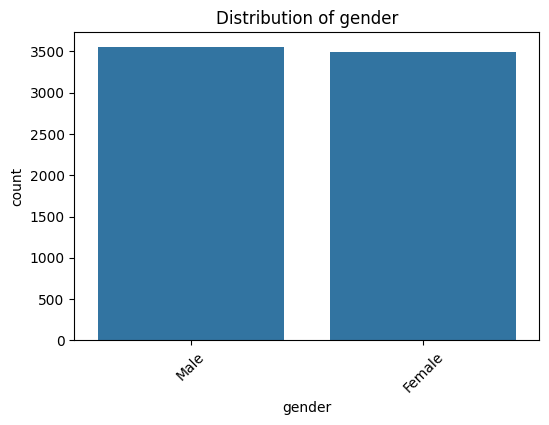

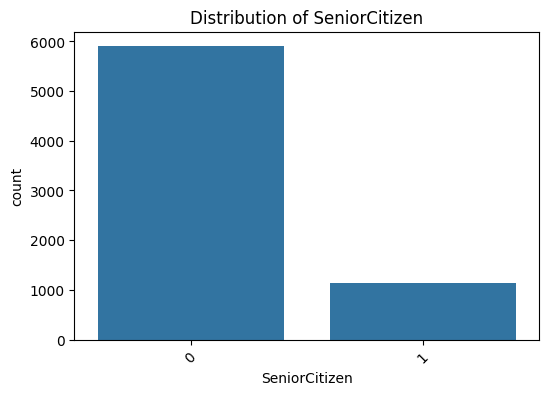

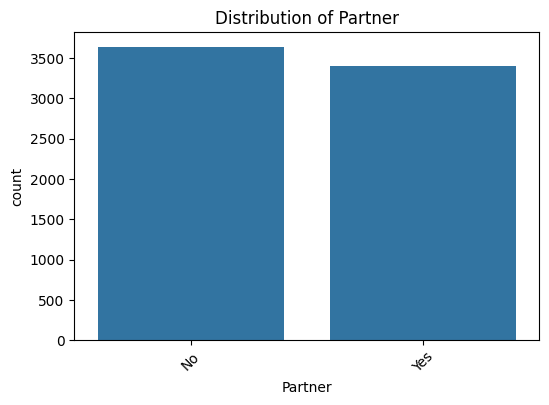

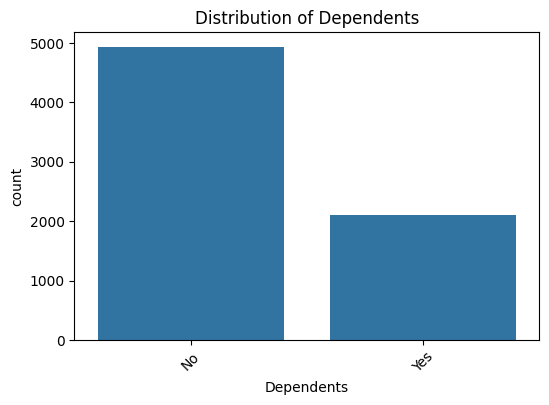

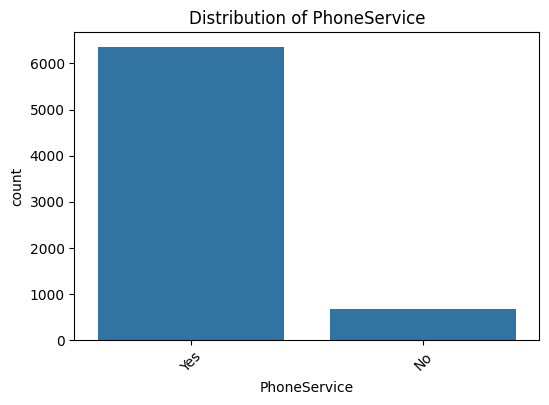

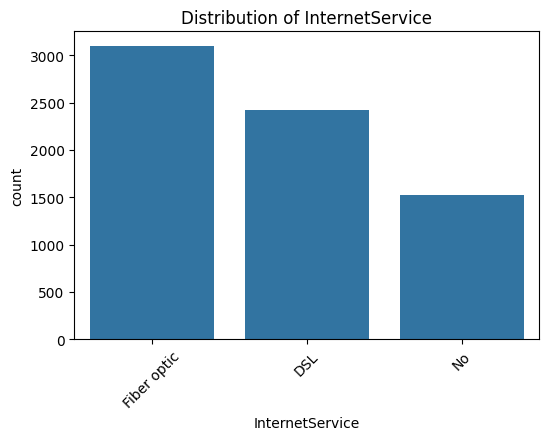

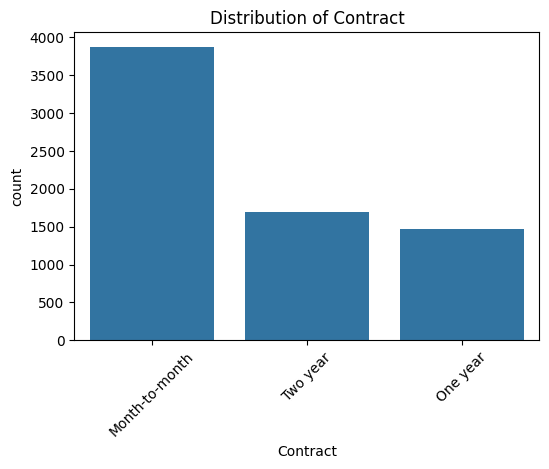

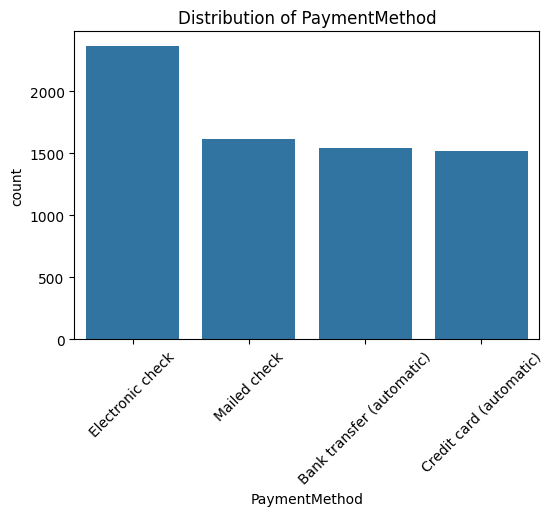

In [ ]:
#Creating count plot to analyse the categorical data
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
num_cols = [
    'tenure',
    'MonthlyCharges'
    ]

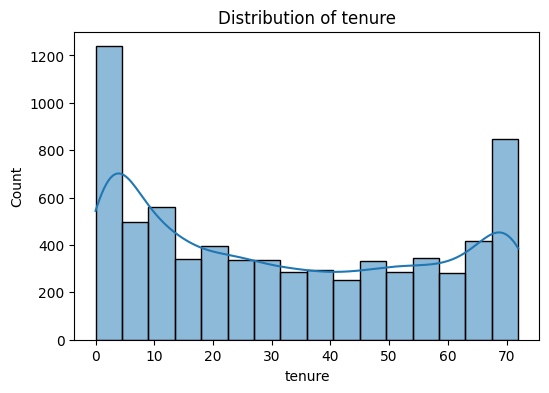

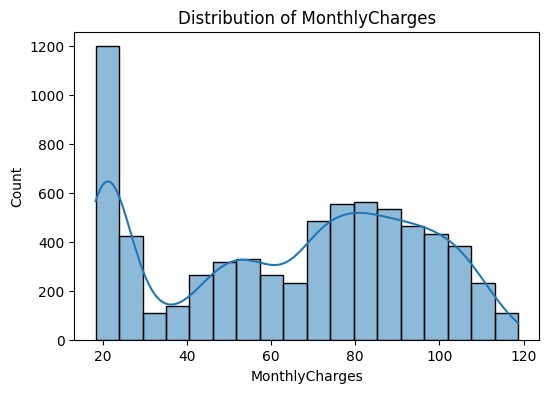

In [ ]:
for num in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(x=num, data=df, kde=True)
    plt.title(f'Distribution of {num}')
    plt.show()

#### Observations -

We see that the distribution of gender is almost the same,we see that most of them are younger audience & very less senior citizens are involved, distribution of dependents are not there for majority,similarly distribution of phone service is not there for majority,Distribution of internet service is highest for Fiber optic, followed by DSL while a group of people dont have the service opted at all, Distribution of tenure is highest for 0-5 month period & similarly at the 67-72 month period being next highest, remaining all have sparse distribution, monthly charges are being comparitively low for a major audience while it ranges from low to high for a cumulatively mass audience group.
Majority of customers are on month-to-month contracts, suggesting flexible contract preference among users.

### Bivariate Analysis

In [ ]:
bi_cat_cols = ['gender',
'SeniorCitizen',
'Partner',
'Dependents',
'InternetService',
'Contract',
'PaymentMethod'
]

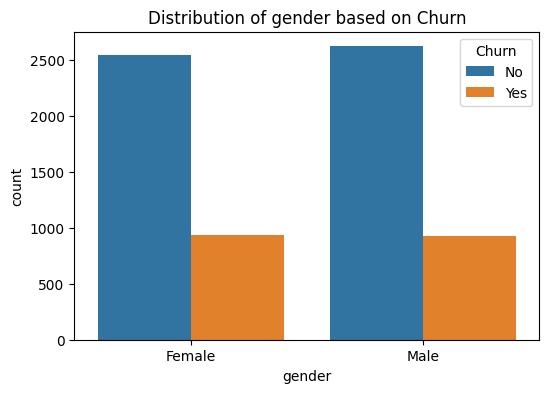

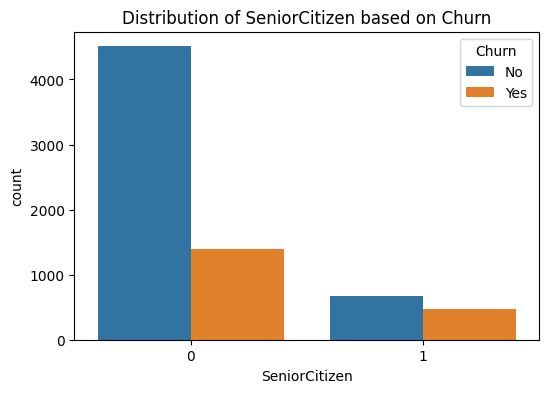

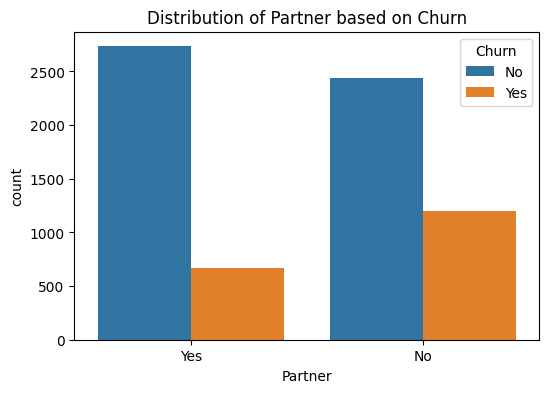

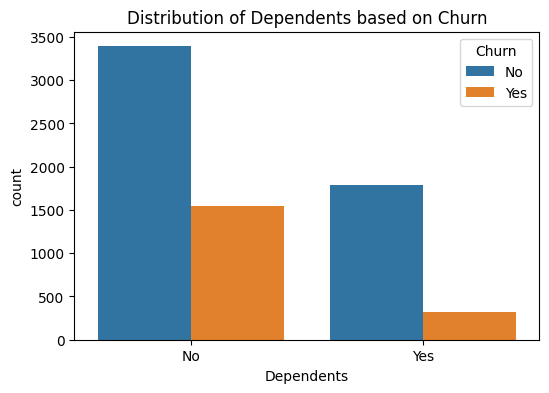

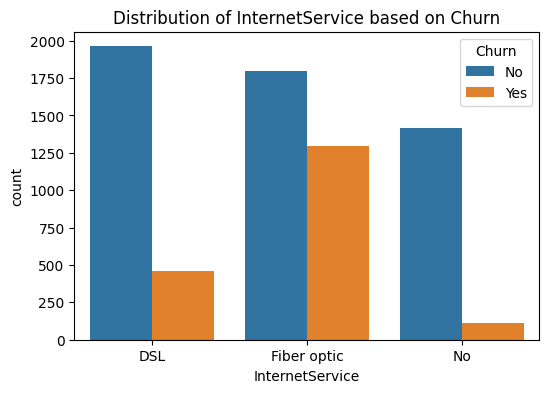

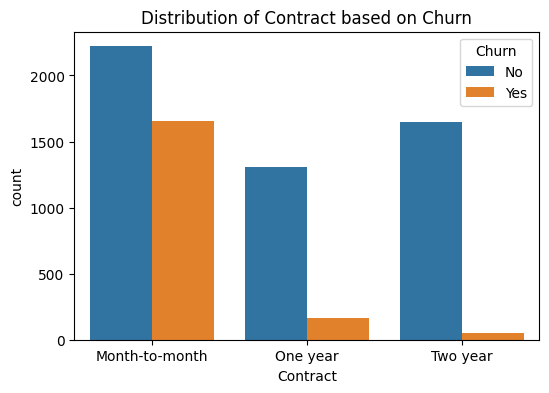

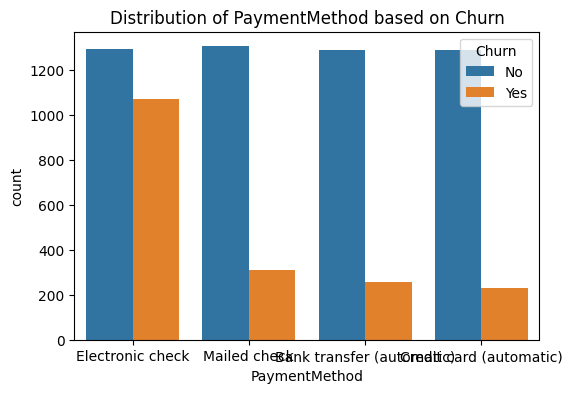

In [ ]:
for col in bi_cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, hue='Churn')
    plt.title(f'Distribution of {col} based on Churn')
    plt.show()

#### Bivariate Analysis Observations -
There's no specific churning pattern in terms of gender, there's a group of audience who tend to churn in both genders,compared to younger audience we see churning is maximum for senior citizens as almost 90% of them churn,we see that where there are no distribution partners, churning is a bit on the higher side, distribution of dependents have low churn compared to no distribution of dependents,Ones using fiber optic internet service have max churn percentage, confirming that is the most reliable service which keeps customers satisfied/provides proper and timely repair,response,month-to-month contract distribution have highest churn compared to long term, people opting for electronic check payment mode have highest churn.

### Data Preprocessing

In [ ]:
#Since customer ID does not have any impact on Customer churning, we will drop it
df_new = df.drop('customerID', axis=1)
df_new.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
#Total charges data type would need fixing if it's not float
df_new['TotalCharges'].dtype

dtype('O')

In [ ]:
df_new['TotalCharges'] = pd.to_numeric(df_new['TotalCharges'], errors='coerce')
df_new.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df_new['TotalCharges'].dtype

dtype('float64')

We see that the Total charges column data is converted to float datatype as expected

In [ ]:
df_new['TotalCharges'].isna().sum()

np.int64(11)

We see that there are 11 missing values is TotalCharges column. Because there rae just 11 rows missing, we can drop the rows with missing values

In [ ]:
df_new = df_new.dropna(subset=['TotalCharges'])
df_new

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
df_new.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


Train Test Split the data

In [ ]:
from sklearn.model_selection import train_test_split

X=df_new.drop('Churn',axis=1)
y=df_new['Churn']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1234,stratify=y)
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")


Training set size: 4922
Testing set size: 2110


To apply one hot encoding to categorical variables

In [ ]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [ ]:
X_train = pd.get_dummies(X_train, drop_first=True)

In [ ]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
X_train.shape

(4922, 30)

In [ ]:
X_test.shape

(2110, 30)

We see that both X_train, X_test have 30 columns, confirming both are aligned after encoding them.

### Training the Model

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

model = LogisticRegression(random_state=1234)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Accuracy: 0.7928909952606635
Confusion Matrix:
[[1387  162]
 [ 275  286]]
Classification Report:
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1549
         Yes       0.64      0.51      0.57       561

    accuracy                           0.79      2110
   macro avg       0.74      0.70      0.72      2110
weighted avg       0.78      0.79      0.78      2110



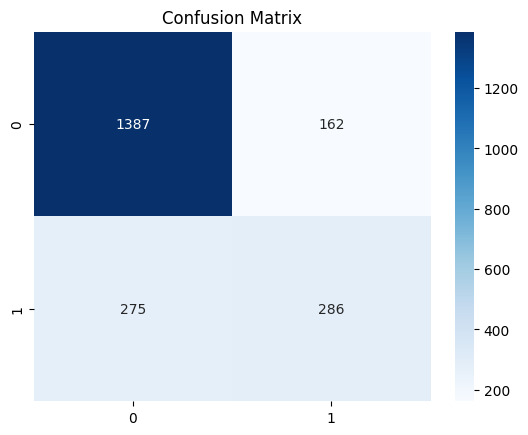

In [ ]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

We see that 286 customers who are predicted to churn did actually churn.

In [ ]:
from sklearn.metrics import roc_auc_score
y_score_log = model.predict_proba(X_test)[:,1]
roc_auc_log = roc_auc_score(y_test, y_score_log)

print("Logistic Regression ROC-AUC:", roc_auc_log)

Logistic Regression ROC-AUC: 0.8256071135537963


#### Observations -

The Logistic Regression baseline model achieved an accuracy of 79%.
However, the recall for churn customers is relatively low (~51%), indicating that the model fails to identify a significant portion of customers who are likely to churn.
This suggests that more complex models may be required to better capture churn patterns.

### Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=1234)
dt_model.fit(X_train, y_train)

dt_y_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_y_pred)
print('Accuracy for DT is : ',dt_accuracy)

dt_cm = confusion_matrix(y_test, dt_y_pred)
print("Confusion Matrix:")
print(dt_cm)

dt_report = classification_report(y_test, dt_y_pred)
print("Classification Report:")
print(dt_report)

Accuracy for DT is :  0.7165876777251184
Confusion Matrix:
[[1240  309]
 [ 289  272]]
Classification Report:
              precision    recall  f1-score   support

          No       0.81      0.80      0.81      1549
         Yes       0.47      0.48      0.48       561

    accuracy                           0.72      2110
   macro avg       0.64      0.64      0.64      2110
weighted avg       0.72      0.72      0.72      2110



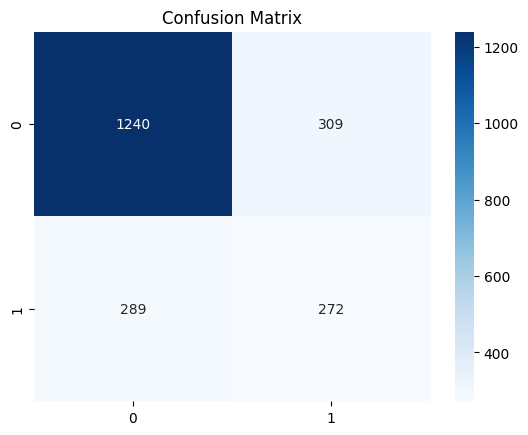

In [ ]:
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
y_score_dt = dt_model.predict_proba(X_test)[:,1]

roc_auc_dt = roc_auc_score(y_test, y_score_dt)

print("Decision Tree ROC-AUC:", roc_auc_dt)

Decision Tree ROC-AUC: 0.6439442846802432


The Decision Tree model achieved an accuracy of 71%, which is lower than the Logistic Regression baseline. Additionally, the recall for churn customers dropped to 47%, indicating that the model fails to capture a significant portion of churn cases. This suggests that a single decision tree may not generalize well for this dataset, and ensemble models such as Random Forest may provide better performance.

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=1234)
rf_model.fit(X_train,y_train)

rf_y_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_y_pred)
print('Accuracy for RF is : ',rf_accuracy)

rf_cm = confusion_matrix(y_test, rf_y_pred)
print("Confusion Matrix:")
print(rf_cm)

rf_report = classification_report(y_test, rf_y_pred)
print("Classification Report:")
print(rf_report)

Accuracy for RF is :  0.7796208530805687
Confusion Matrix:
[[1397  152]
 [ 313  248]]
Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.90      0.86      1549
         Yes       0.62      0.44      0.52       561

    accuracy                           0.78      2110
   macro avg       0.72      0.67      0.69      2110
weighted avg       0.76      0.78      0.77      2110



In [ ]:
y_score_rf = rf_model.predict_proba(X_test)[:,1]

roc_auc_rf = roc_auc_score(y_test, y_score_rf)

print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest ROC-AUC: 0.8149378185454591


### Logistic Regression with Class weights

In [ ]:
log_model = LogisticRegression(class_weight='balanced', random_state=1234)
log_model.fit(X_train, y_train)

log_y_pred = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, log_y_pred)
print('Accuracy for Log is : ',log_accuracy)

log_cm = confusion_matrix(y_test, log_y_pred)
print("Confusion Matrix:")
print(log_cm)

log_report = classification_report(y_test, log_y_pred)
print("Classification Report:")
print(log_report)


Accuracy for Log is :  0.737914691943128
Confusion Matrix:
[[1139  410]
 [ 143  418]]
Classification Report:
              precision    recall  f1-score   support

          No       0.89      0.74      0.80      1549
         Yes       0.50      0.75      0.60       561

    accuracy                           0.74      2110
   macro avg       0.70      0.74      0.70      2110
weighted avg       0.79      0.74      0.75      2110



In [ ]:
y_score_log_bal = log_model.predict_proba(X_test)[:,1]

roc_auc_log_bal = roc_auc_score(y_test, y_score_log_bal)

print("Logistic Regression Balanced ROC-AUC:", roc_auc_log_bal)

Logistic Regression Balanced ROC-AUC: 0.8264552255552142


Observation -

We see that the recall has significant improvement showing that prioritising & penalizing the errors of minority class actually helps improve identification of customers who will churn.

### RandomForest with Class weights

In [ ]:
rf1_model = RandomForestClassifier(class_weight='balanced', random_state=1234)

rf1_model.fit(X_train, y_train)

rf1_y_pred = rf1_model.predict(X_test)

rf1_accuracy = accuracy_score(y_test, rf1_y_pred)
print('Accuracy for RF with weights',rf1_accuracy)

rf1_cm = confusion_matrix(y_test, rf1_y_pred)
print("Confusion Matrix:")
print(rf1_cm)

rf1_report = classification_report(y_test, rf1_y_pred)
print("Classification Report:")
print(rf1_report)

Accuracy for RF with weights 0.7819905213270142
Confusion Matrix:
[[1405  144]
 [ 316  245]]
Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.91      0.86      1549
         Yes       0.63      0.44      0.52       561

    accuracy                           0.78      2110
   macro avg       0.72      0.67      0.69      2110
weighted avg       0.77      0.78      0.77      2110



As we see that the Logistic regression model with class weights has the best recall of all & for this problem, recall being the important factor than accuracy, we'll consider the Logistic Regression with weights & tune it further to see if recall improves

In [ ]:
print(model.classes_)

['No' 'Yes']


In [ ]:
#To generate probabilities for log_model , gives model confidence

y_score = log_model.predict_proba(X_test)[:,1]
print(y_score)

[0.16184048 0.67980429 0.55379406 ... 0.00681184 0.02595992 0.93116635]


In [ ]:
y_pred_default = model.predict(X_test)
print(y_pred_default)

['No' 'No' 'No' ... 'No' 'No' 'Yes']


In [ ]:
threshold=0.35
y_pred_new = (y_score>=threshold)
print(y_pred_new)

[False  True  True ... False False  True]


In [ ]:
acc_default = accuracy_score(y_test,y_pred_default)
print(acc_default)

cm_default = confusion_matrix(y_test,y_pred_default)
print(cm_default)

report_default = classification_report(y_test,y_pred_default)
print(report_default)

0.7928909952606635
[[1387  162]
 [ 275  286]]
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1549
         Yes       0.64      0.51      0.57       561

    accuracy                           0.79      2110
   macro avg       0.74      0.70      0.72      2110
weighted avg       0.78      0.79      0.78      2110



In [ ]:
y_pred_new = np.where(y_pred_new, 'Yes', 'No')

acc_new = accuracy_score(y_test,y_pred_new)
print(acc_new)

cm_new = confusion_matrix(y_test,y_pred_new)
print(cm_new)

report_new = classification_report(y_test,y_pred_new)
print(report_new)

0.6748815165876777
[[931 618]
 [ 68 493]]
              precision    recall  f1-score   support

          No       0.93      0.60      0.73      1549
         Yes       0.44      0.88      0.59       561

    accuracy                           0.67      2110
   macro avg       0.69      0.74      0.66      2110
weighted avg       0.80      0.67      0.69      2110



In [ ]:
y_score_rf_bal = rf1_model.predict_proba(X_test)[:,1]

roc_auc_rf_bal = roc_auc_score(y_test, y_score_rf_bal)

print("Random Forest Balanced ROC-AUC:", roc_auc_rf_bal)

Random Forest Balanced ROC-AUC: 0.8157807521153893


Observations -
Lowering the classification threshold from the default value of 0.5 to 0.35 significantly improves the recall for churn customers (0.88). This means the model is able to correctly identify approximately 88% of customers who are likely to churn. Although precision decreases due to an increase in false positives, this trade-off is acceptable because the business objective is to identify as many potential churn customers as possible. These identified customers can then be targeted with retention strategies such as promotional discounts, subscription offers, or customer engagement programs.

### Random Forest Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_dist = {
    'n_estimators': [100,200,300],
    'max_depth': [5,10,15,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_features': ['sqrt','log2']
}

In [ ]:
rf_model = RandomForestClassifier(class_weight='balanced', random_state=1234)

rf_random = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='recall',
    random_state=1234,
    n_jobs=-1
)

In [ ]:
rf_random.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=1234),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=1234, scoring='recall')

In [ ]:
rf_random.best_params_

{'n_estimators': 300,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 5}

In [ ]:
best_rf = rf_random.best_estimator_
print(best_rf)

RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_split=5, n_estimators=300,
                       random_state=1234)


In [ ]:
rf_pred = best_rf.predict(X_test)
print(rf_pred)

['No' 'Yes' 'Yes' ... 'No' 'No' 'Yes']


In [ ]:
print(accuracy_score(y_test, rf_pred))

print(confusion_matrix(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

0.738388625592417
[[1138  411]
 [ 141  420]]
              precision    recall  f1-score   support

          No       0.89      0.73      0.80      1549
         Yes       0.51      0.75      0.60       561

    accuracy                           0.74      2110
   macro avg       0.70      0.74      0.70      2110
weighted avg       0.79      0.74      0.75      2110



In [ ]:
rf_scores = best_rf.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import roc_auc_score

rf_auc = roc_auc_score(y_test, rf_scores)
print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.8320634668563123


### Observations -

Among the models evaluated, Logistic Regression with class weighting and threshold tuning achieved the highest recall (≈0.88), indicating that it is most effective at identifying customers likely to churn. While Random Forest and Decision Tree models provide reasonable performance, the simpler Logistic Regression model performs best for this dataset. Since churn prediction prioritizes identifying at-risk customers, this model is selected as the final model.

In [ ]:
#Accuracy Score

from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_new)

0.6748815165876777

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_new)
print(cm)

[[931 618]
 [ 68 493]]


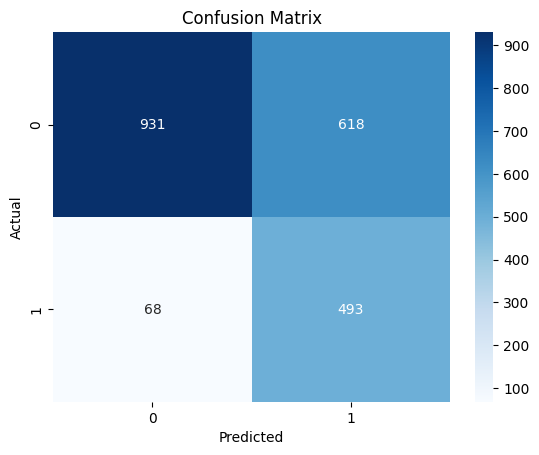

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

          No       0.93      0.60      0.73      1549
         Yes       0.44      0.88      0.59       561

    accuracy                           0.67      2110
   macro avg       0.69      0.74      0.66      2110
weighted avg       0.80      0.67      0.69      2110



### Model Explanation & Validation

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_score)

np.float64(0.8264552255552142)

The model has an 82.6% probability of ranking a churn customer
higher than a non-churn customer.

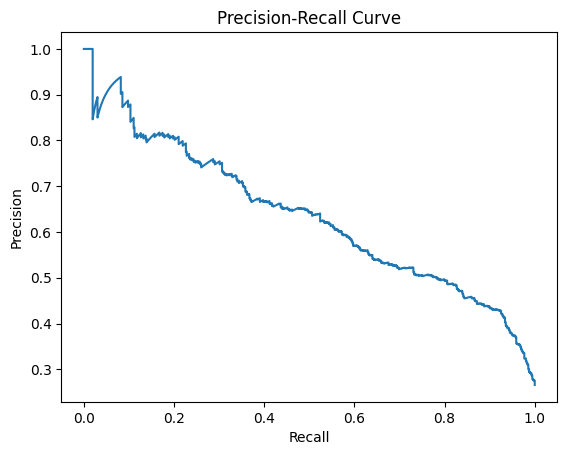

In [ ]:
#as our dataset is imbalanced, Precision-Recall curve is more informative than ROC AUC
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_score, pos_label='Yes')

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
#Logistic Regression coefficient shows how feature influences the customer churn
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

feature_importance.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
10,InternetService_Fiber optic,0.532667
26,PaperlessBilling_Yes,0.469082
8,MultipleLines_No phone service,0.269866
0,SeniorCitizen,0.239293
9,MultipleLines_Yes,0.235741
28,PaymentMethod_Electronic check,0.187310
23,StreamingMovies_Yes,0.185119
21,StreamingTV_Yes,0.182789
4,gender_Male,0.009266
2,MonthlyCharges,0.005542


#### Observation -

We see that the Internet Service using Fiber optic,PaperlessBilling_Yes,MultipleLines_No phone service are some of the contributing factors to increase churn while TechSupport_Yes,Contract_Two year	,OnlineSecurity_Yes & similar features decreases churn.

In [ ]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Logistic Regression Balanced",
        "Decision Tree",
        "Random Forest",
        "Random Forest Balanced",
        "Random Forest Tuned"
    ],
    "ROC-AUC":[
        roc_auc_log,
        roc_auc_log_bal,
        roc_auc_dt,
        roc_auc_rf,
        roc_auc_rf_bal,
        rf_auc
    ]
})

print(results.sort_values(by="ROC-AUC", ascending=False))

                          Model   ROC-AUC
5           Random Forest Tuned  0.832063
1  Logistic Regression Balanced  0.826455
0           Logistic Regression  0.825607
4        Random Forest Balanced  0.815781
3                 Random Forest  0.814938
2                 Decision Tree  0.643944


### Conclusion -

Key Insights

Analysis of the churn prediction model reveals several important factors influencing customer churn.

Customers using fiber optic internet services show higher churn probability, indicating possible dissatisfaction with pricing, service quality, or reliability. Additionally, customers opting for paperless billing and electronic check payments tend to churn more frequently, which may indicate a segment of customers who prefer flexibility and are more likely to switch providers.

Senior citizens also demonstrate slightly higher churn rates, suggesting that service usability or customer support may influence their decision to leave.

Conversely, customers with long-term contracts (one-year or two-year) exhibit significantly lower churn rates, indicating that contractual commitments improve retention. Similarly, customers using technical support, online security services, and additional service bundles are less likely to churn, highlighting the value of service engagement and product bundling.

Recommended Business Actions

Based on these findings, several strategies can be implemented to reduce churn:

1. Encourage long-term contracts

Provide incentives such as discounted pricing or loyalty rewards for customers who switch from month-to-month plans to one-year or two-year contracts.

2. Improve fiber optic service experience

Investigate potential service issues related to fiber optic users, including pricing concerns or service reliability, and implement improvements where necessary.

3. Promote value-added services

Encourage adoption of services such as technical support, online security, and backup services, as these features are associated with lower churn rates.

4. Target high-risk customers proactively

Using the churn prediction model, identify customers with high churn probability and offer retention campaigns such as promotional discounts, service upgrades, or personalized engagement.

5. Improve support for senior customers

Provide simplified service options and improved customer support for senior citizens to enhance their experience and reduce churn risk.